# Umfassender Modellvergleich: Sprachkomplexitäts- & Reward-Metriken
#### Empirische Gesamtevaluation: BiLSTM (MixUp) vs. Synthetischer LLM-Regressor vs. Vanilla RNN Baseline

---

## 1. Überblick & Fragestellung

Dieses Notebook führt die Auswertungen aller Metrik- und Regressionsmodelle  in einer konsolidierten Gesamtschau zusammen:

1. **Architektur-Ablation:** BiLSTM (Hauptmodell) vs. Vanilla RNN (Ablation Baseline).
2. **Binäre Diskriminierung (Lebenshilfe-Goldstandard):** Dichteverteilungen (KDE) und statistische Gütekriterien bei der Trennung von Leichter Sprache ($LS$) und Alltagssprache ($AS$).
3. **Symmetrische Kreuzvalidierung (Cross-Validation):** Vollständiger Vergleich von **MixUp-Regressor** und **Synthetischem Regressor** auf **beiden** komplementären Datensätzen:
   - **Datensatz A: LLM-Synthetisierte Stufen (245 Samples):** 5 semantisch formulierte Komplexitätsstufen ($0.00 = LS, 0.25, 0.50, 0.75, 1.00 = AS$).
   - **Datensatz B: Sentence-Level MixUp (490 Samples):** Reale Lebenshilfe-Satzpaare mit kontinuierlichen Mischungsanteilen.
4. **Wissenschaftliche Schlussfolgerung für Step 3:** Festlegung des optimalen Reward-Modells für das DPO-Training.


In [9]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display, HTML
except ImportError:
    def display(*args):
        for a in args:
            print(a)
    class HTML:
        def __init__(self, data):
            self.data = data

while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir("..")

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

PLOT_OUTPUT_DIR = "results/plots"
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)
print("Arbeitsverzeichnis:", os.getcwd())


Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis


In [10]:
# Statistische Metrik-Funktionen
try:
    from scipy.stats import pearsonr, spearmanr, wasserstein_distance, ks_2samp
except ImportError:
    def pearsonr(x, y):
        return float(np.corrcoef(x, y)[0, 1]), 0.0
    def spearmanr(x, y):
        rx, ry = np.argsort(np.argsort(x)), np.argsort(np.argsort(y))
        return float(np.corrcoef(rx, ry)[0, 1]), 0.0
    def wasserstein_distance(u, v):
        all_vals = np.sort(np.concatenate([u, v]))
        u_cdf = np.searchsorted(np.sort(u), all_vals, side='right') / len(u)
        v_cdf = np.searchsorted(np.sort(v), all_vals, side='right') / len(v)
        return float(np.sum(np.abs(u_cdf[:-1] - v_cdf[:-1]) * np.diff(all_vals)))
    def ks_2samp(u, v):
        all_vals = np.sort(np.concatenate([u, v]))
        u_cdf = np.searchsorted(np.sort(u), all_vals, side='right') / len(u)
        v_cdf = np.searchsorted(np.sort(v), all_vals, side='right') / len(v)
        return float(np.max(np.abs(u_cdf - v_cdf))), 0.0

try:
    from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, balanced_accuracy_score, precision_recall_fscore_support, mean_squared_error, mean_absolute_error
except ImportError:
    def roc_curve(y_true, y_scores):
        thresholds = np.concatenate([[1.01], np.sort(np.unique(y_scores))[::-1], [-0.01]])
        P, N = max(np.sum(y_true == 1), 1), max(np.sum(y_true == 0), 1)
        tpr = [np.sum((y_scores >= t) & (y_true == 1)) / P for t in thresholds]
        fpr = [np.sum((y_scores >= t) & (y_true == 0)) / N for t in thresholds]
        return np.array(fpr), np.array(tpr), thresholds
    def roc_auc_score(y_true, y_scores):
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        return float(np.trapezoid(tpr, fpr)) if hasattr(np, 'trapezoid') else float(np.trapz(tpr, fpr))
    def accuracy_score(y_true, y_pred):
        return float(np.mean(y_true == y_pred))
    def balanced_accuracy_score(y_true, y_pred):
        return float((np.mean(y_pred[y_true == 1] == 1) + np.mean(y_pred[y_true == 0] == 0)) / 2.0)
    def precision_recall_fscore_support(y_true, y_pred, average="binary", pos_label=1, zero_division=0):
        tp, fp, fn = np.sum((y_true == 1) & (y_pred == 1)), np.sum((y_true == 0) & (y_pred == 1)), np.sum((y_true == 1) & (y_pred == 0))
        prec = tp / max(tp + fp, 1e-9)
        rec = tp / max(tp + fn, 1e-9)
        f1 = 2 * prec * rec / max(prec + rec, 1e-9)
        return prec, rec, f1, None
    def mean_squared_error(y_true, y_pred):
        return float(np.mean((y_true - y_pred) ** 2))
    def mean_absolute_error(y_true, y_pred):
        return float(np.mean(np.abs(y_true - y_pred)))


## 2. Evaluationsdaten laden


In [11]:
# Evaluations-CSVs einlesen
df_bilstm_rnn_preds = pd.read_csv("results/evaluation/bilstm_vs_rnn_predictions.csv")
df_kde = pd.read_csv("results/evaluation/mixup_synthetic_kde_eval.csv")
df_unbiased_eval = pd.read_csv("results/evaluation/mixup_vs_synthetic_unbiased_eval.csv")

# Arrays extrahieren
ls_preds_bilstm = df_bilstm_rnn_preds["ls_pred_bilstm"].to_numpy()
as_preds_bilstm = df_bilstm_rnn_preds["as_pred_bilstm"].to_numpy()
ls_preds_rnn = df_bilstm_rnn_preds["ls_pred_rnn"].to_numpy()
as_preds_rnn = df_bilstm_rnn_preds["as_pred_rnn"].to_numpy()

ls_preds_synth = df_kde["synth_ls_score"].to_numpy()
as_preds_synth = df_kde["synth_as_score"].to_numpy()

print(f"Datensätze geladen: {len(df_bilstm_rnn_preds)} Artikelpaare (BiLSTM, Synthetisch, RNN).")


Datensätze geladen: 37 Artikelpaare (BiLSTM, Synthetisch, RNN).


## 3. Zentrale Master-Vergleichstabelle (Lebenshilfe-Goldstandard)

Gegenüberstellung aller drei Kernmodelle auf der binären Diskriminierung (LS vs. AS):
- **BiLSTM (MixUp):** Hauptmodell trainiert auf Satzmischungen.
- **Synthetischer Regressor:** BiLSTM trainiert auf 5 semantischen LLM-Stufen.
- **Vanilla RNN Baseline:** Unidirektionale rekurrente Baseline ohne LSTM-Gates.


In [12]:
def evaluate_model_metrics(ls_scores, as_scores, name, arch, paradigm):
    y_true = np.array([1] * len(ls_scores) + [0] * len(as_scores))
    y_scores = np.concatenate([ls_scores, as_scores])
    y_pred = (y_scores >= 0.5).astype(int)
    
    mean_ls, std_ls = float(np.mean(ls_scores)), float(np.std(ls_scores))
    mean_as, std_as = float(np.mean(as_scores)), float(np.std(as_scores))
    separation = float(mean_ls - mean_as)
    
    acc = float(accuracy_score(y_true, y_pred))
    bacc = float(balanced_accuracy_score(y_true, y_pred))
    try:
        prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", pos_label=1, zero_division=0)
        f1_val = float(np.mean(f1))
    except Exception:
        tp, fp, fn = np.sum((y_true == 1) & (y_pred == 1)), np.sum((y_true == 0) & (y_pred == 1)), np.sum((y_true == 1) & (y_pred == 0))
        prec = tp / max(tp + fp, 1e-9)
        rec = tp / max(tp + fn, 1e-9)
        f1_val = float(2 * prec * rec / max(prec + rec, 1e-9))
        
    auc = float(roc_auc_score(y_true, y_scores))
    w_dist = float(wasserstein_distance(ls_scores, as_scores))
    ks_res = ks_2samp(ls_scores, as_scores)
    ks_stat = float(ks_res[0] if isinstance(ks_res, (tuple, list)) else ks_res.statistic)
    
    return {
        "Modell": name,
        "Architektur": arch,
        "Trainingsparadigma": paradigm,
        "Ø Lambda (LS)": f"{mean_ls:.4f} ± {std_ls:.3f}",
        "Ø Lambda (AS)": f"{mean_as:.4f} ± {std_as:.3f}",
        "Separation (Δ)": f"{separation:.4f}",
        "Accuracy (@0.5)": f"{acc * 100:.2f}%",
        "Balanced Acc": f"{bacc * 100:.2f}%",
        "F1-Score": f"{f1_val * 100:.2f}%",
        "ROC-AUC": f"{auc:.4f}",
        "Wasserstein (W1)": f"{w_dist:.4f}",
        "KS-Statistik (D)": f"{ks_stat:.4f}"
    }

master_table = pd.DataFrame([
    evaluate_model_metrics(ls_preds_bilstm, as_preds_bilstm, "BiLSTM (MixUp)", "BiLSTM (2x128)", "Sentence-MixUp"),
    evaluate_model_metrics(ls_preds_synth, as_preds_synth, "Synthetischer Regressor", "BiLSTM (2x128)", "LLM-Stufen (0-1)"),
    evaluate_model_metrics(ls_preds_rnn, as_preds_rnn, "Vanilla RNN (Baseline)", "RNN Uni (128)", "Sentence-MixUp")
])

display(master_table)


,Modell,Architektur,Trainingsparadigma,Ø Lambda (LS),Ø Lambda (AS),Separation (Δ),Accuracy (@0.5),Balanced Acc,F1-Score,ROC-AUC,Wasserstein (W1),KS-Statistik (D)
0,BiLSTM (MixUp),BiLSTM (2x128),Sentence-MixUp,0.6707 ± 0.123,0.1725 ± 0.091,0.4982,93.24%,93.24%,92.75%,0.9953,0.4982,0.9459
1,Synthetischer Regressor,BiLSTM (2x128),LLM-Stufen (0-1),0.6502 ± 0.249,0.1390 ± 0.111,0.5112,89.19%,89.19%,87.88%,0.9430,0.5112,0.8649
2,Vanilla RNN (Baseline),RNN Uni (128),Sentence-MixUp,0.4539 ± 0.089,0.3439 ± 0.092,0.1100,59.46%,59.46%,44.44%,0.8221,0.1100,0.6216


## 4. Abbildung 1: Dichteverteilungen (KDE) aller Modelle auf Lebenshilfe

Vergleich der vorhergesagten Lambda-Dichteverteilungen für Leichte Sprache (grün) und Alltagssprache (blau) im standardisierten Maßstab.


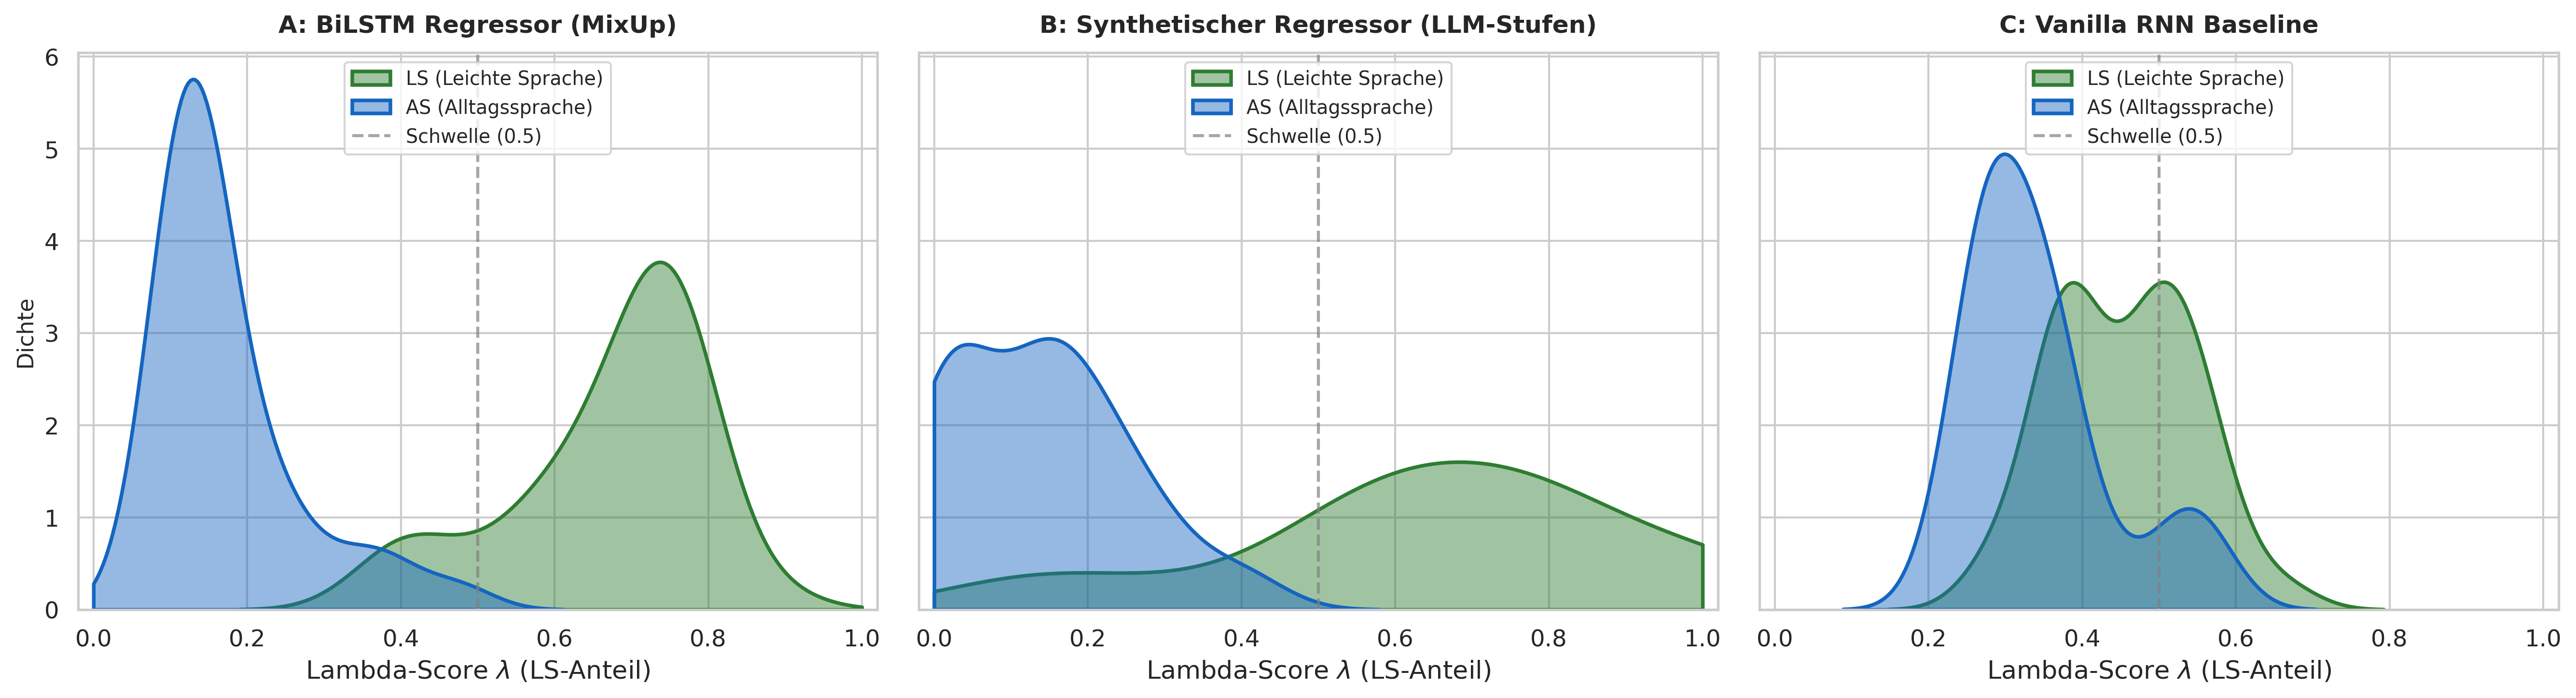

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

models_data = [
    ("A: BiLSTM Regressor (MixUp)", ls_preds_bilstm, as_preds_bilstm, axes[0]),
    ("B: Synthetischer Regressor (LLM-Stufen)", ls_preds_synth, as_preds_synth, axes[1]),
    ("C: Vanilla RNN Baseline", ls_preds_rnn, as_preds_rnn, axes[2])
]

for title, ls_p, as_p, ax in models_data:
    sns.kdeplot(ls_p, ax=ax, fill=True, color="#2E7D32", alpha=0.45, label="LS (Leichte Sprache)", linewidth=1.8, clip=(0.0, 1.0))
    sns.kdeplot(as_p, ax=ax, fill=True, color="#1565C0", alpha=0.45, label="AS (Alltagssprache)", linewidth=1.8, clip=(0.0, 1.0))
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel(r"Lambda-Score $\lambda$ (LS-Anteil)")
    ax.set_xlim(-0.02, 1.02)
    ax.axvline(0.5, color="gray", linestyle="--", alpha=0.7, label="Schwelle (0.5)")
    ax.legend(loc="upper center", frameon=True, fontsize=9.5)

axes[0].set_ylabel("Dichte", fontsize=11)
plt.tight_layout()
fig.savefig(os.path.join(PLOT_OUTPUT_DIR, "compare_all_models_tri_kde.png"), dpi=300, bbox_inches="tight")
plt.show()


## 5. Abbildung 2: Architektur-Ablation – BiLSTM vs. Vanilla RNN Baseline

Vergleich der Diskriminationsschärfe (ROC-Kurven) und der Streuung nach Textart.


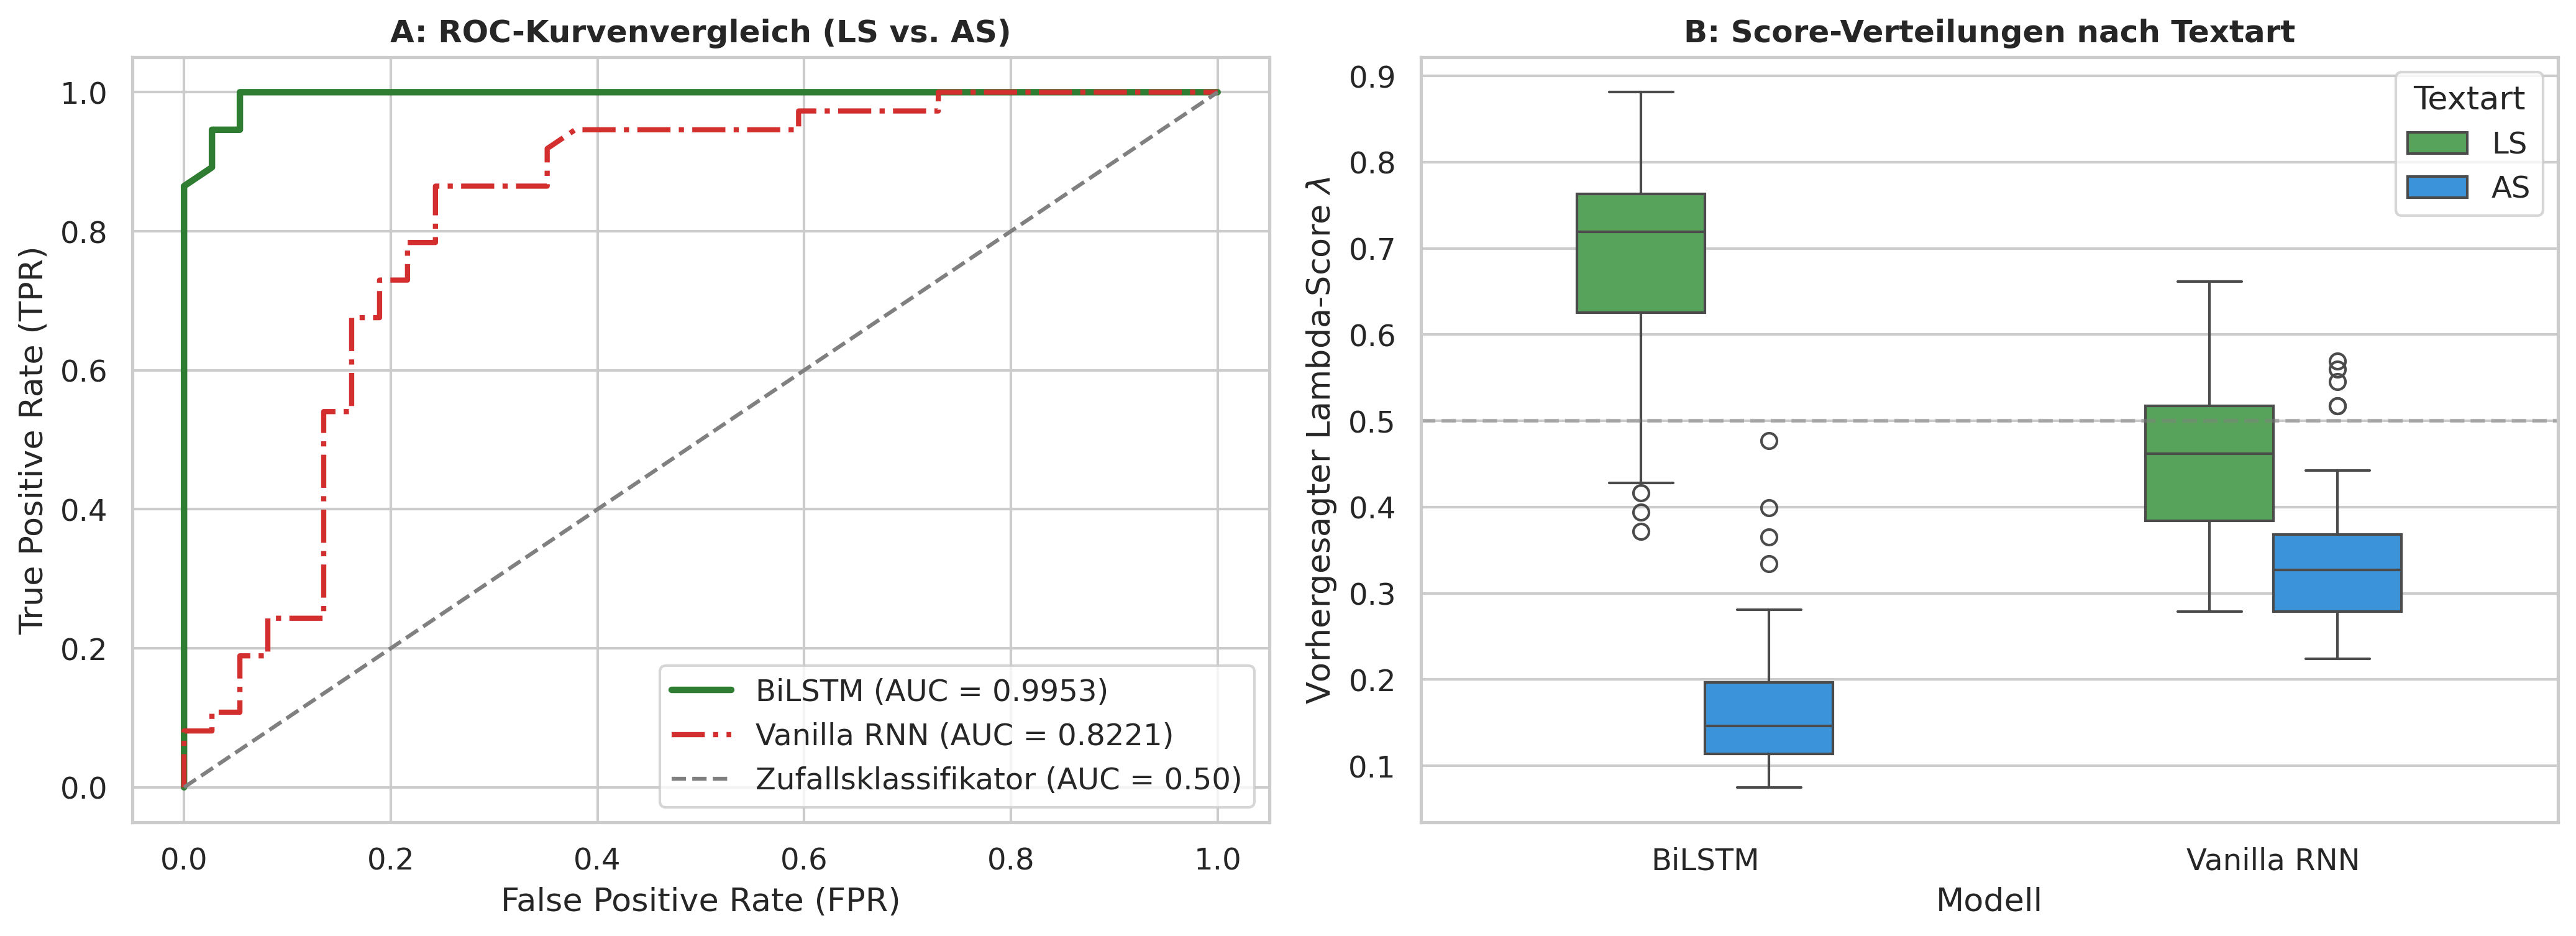

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# ROC-Kurven
y_true = np.array([1] * len(ls_preds_bilstm) + [0] * len(as_preds_bilstm))
fpr_bilstm, tpr_bilstm, _ = roc_curve(y_true, np.concatenate([ls_preds_bilstm, as_preds_bilstm]))
fpr_rnn, tpr_rnn, _ = roc_curve(y_true, np.concatenate([ls_preds_rnn, as_preds_rnn]))
auc_bilstm = roc_auc_score(y_true, np.concatenate([ls_preds_bilstm, as_preds_bilstm]))
auc_rnn = roc_auc_score(y_true, np.concatenate([ls_preds_rnn, as_preds_rnn]))

axes[0].plot(fpr_bilstm, tpr_bilstm, color="#2E7D32", lw=2.5, label=f"BiLSTM (AUC = {auc_bilstm:.4f})")
axes[0].plot(fpr_rnn, tpr_rnn, color="#D32F2F", lw=2, linestyle="-.", label=f"Vanilla RNN (AUC = {auc_rnn:.4f})")
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Zufallsklassifikator (AUC = 0.50)")
axes[0].set_title("A: ROC-Kurvenvergleich (LS vs. AS)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("False Positive Rate (FPR)")
axes[0].set_ylabel("True Positive Rate (TPR)")
axes[0].legend(loc="lower right", frameon=True)

# Boxplot
df_box_arch = pd.DataFrame({
    "Score": np.concatenate([ls_preds_bilstm, as_preds_bilstm, ls_preds_rnn, as_preds_rnn]),
    "Textart": ["LS"] * len(ls_preds_bilstm) + ["AS"] * len(as_preds_bilstm) + ["LS"] * len(ls_preds_rnn) + ["AS"] * len(as_preds_rnn),
    "Modell": ["BiLSTM"] * (2 * len(ls_preds_bilstm)) + ["Vanilla RNN"] * (2 * len(ls_preds_rnn))
})

sns.boxplot(x="Modell", y="Score", hue="Textart", data=df_box_arch, ax=axes[1], palette=["#4CAF50", "#2196F3"], width=0.45)
axes[1].set_title("B: Score-Verteilungen nach Textart", fontsize=12, fontweight="bold")
axes[1].set_ylabel(r"Vorhergesagter Lambda-Score $\lambda$")
axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
fig.savefig(os.path.join(PLOT_OUTPUT_DIR, "compare_bilstm_vs_rnn_roc_box.png"), dpi=300, bbox_inches="tight")
plt.show()


## 6. Symmetrische Kreuzvalidierung: MixUp vs. Synthetisch auf beiden Datensätzen

Um Methoden-Bias auszuschließen, testen wir beide Modelle kreuzweise auf zwei komplementären Datensätzen:
1. **Datensatz A: LLM-Synthetisierte Stufen (245 Samples):** 5 semantisch formulierte Komplexitätsstufen ($0.00 = LS, 0.25, 0.50, 0.75, 1.00 = AS$).
2. **Datensatz B: Sentence-Level MixUp (490 Samples):** Reale Lebenshilfe-Satzpaare mit kontinuierlichen Mischungsanteilen.


In [15]:
print("==========================================================================================")
print("             KREUZVALIDIERUNG: MIXUP-REGRESSOR VS. SYNTHETISCHER REGRESSOR               ")
print("==========================================================================================")
display(df_unbiased_eval)


             KREUZVALIDIERUNG: MIXUP-REGRESSOR VS. SYNTHETISCHER REGRESSOR               


,dataset,model,mae,mse,r2,pearson,spearman
0,LLM Synthetic Steps,MixUp Regressor,0.3079,0.1388,0.3211,0.6626,0.5885
1,LLM Synthetic Steps,Synthetic Regressor,0.1816,0.0786,0.6154,0.7412,0.7391
2,Sentence-MixUp,MixUp Regressor,0.2302,0.0892,0.5412,0.6939,0.7045
3,Sentence-MixUp,Synthetic Regressor,0.2629,0.1162,0.4021,0.5979,0.5917


## 7. Abbildung 3: Regression & Boxplots – Kreuzvalidierung auf beiden Datensätzen

Direkter 2-Spalten-Vergleich:
- **Linke Spalte:** Datensatz A (LLM-Synthetisierte Stufen) – Misst linguistische Komplexitätsabstufungen.
- **Rechte Spalte:** Datensatz B (Sentence-MixUp) – Misst Satzmischungsverhältnisse.


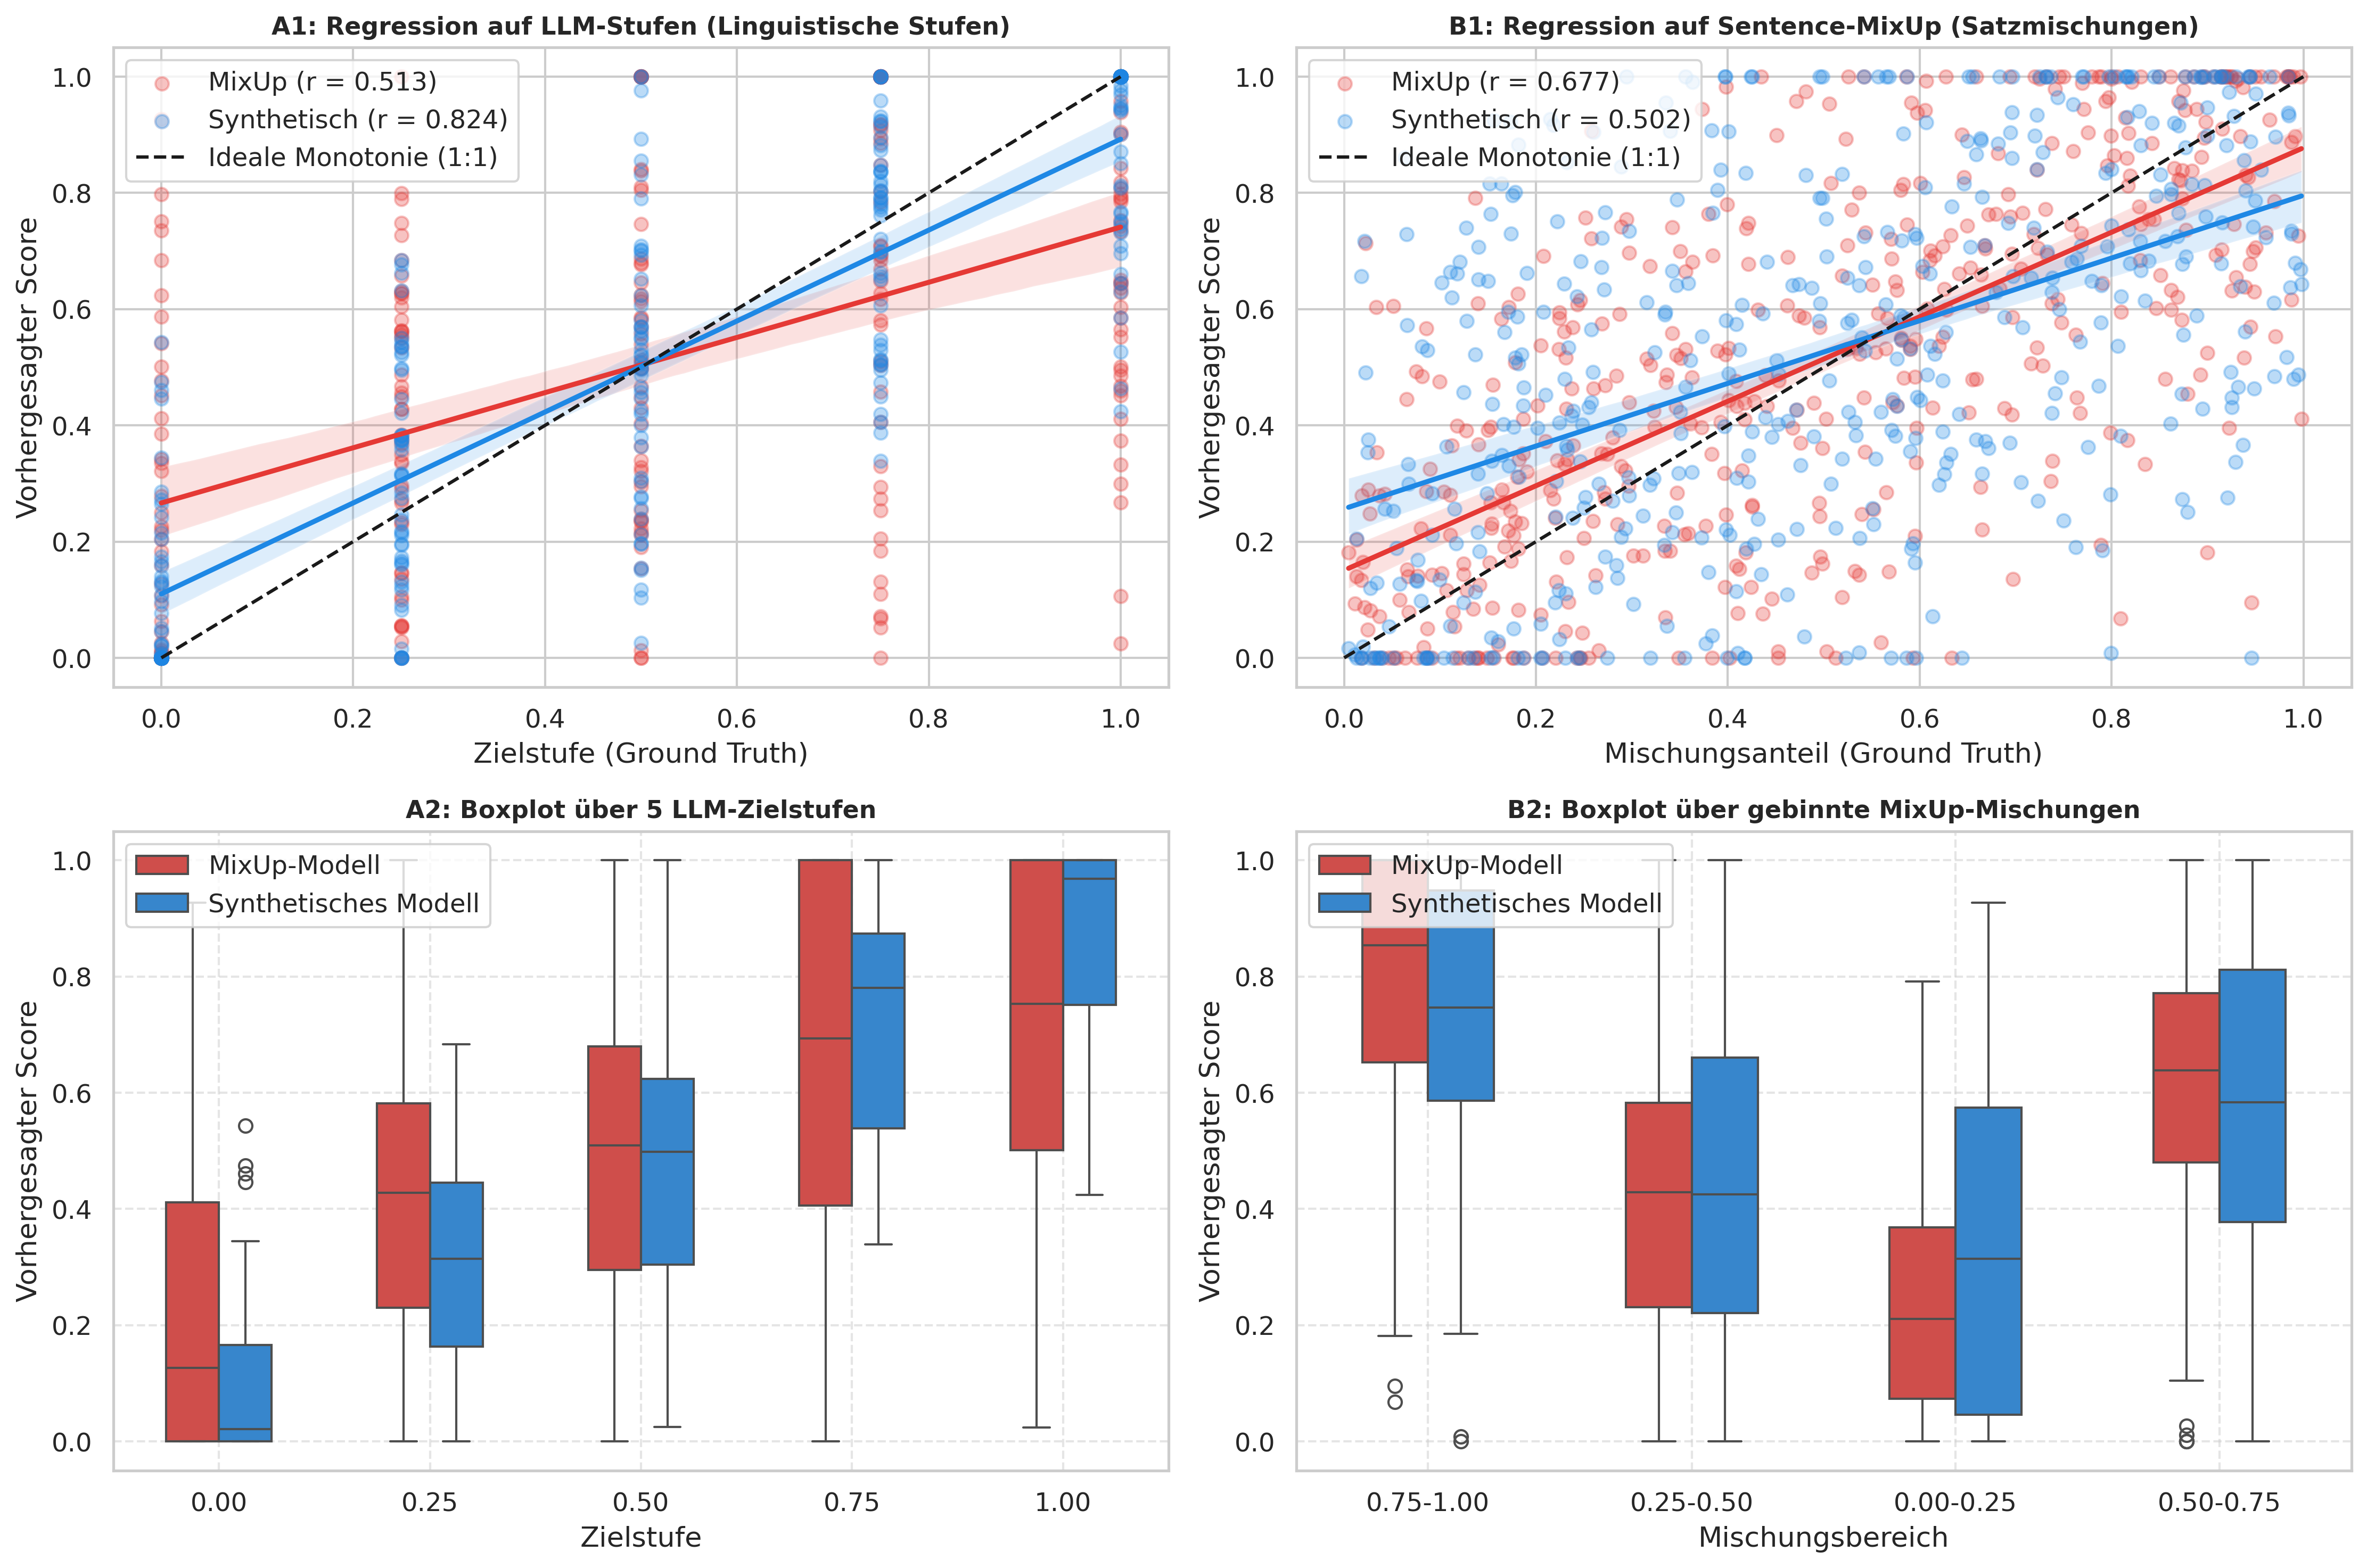

In [16]:
np.random.seed(42)

# Datensatz A: LLM-Stufen (5 diskrete Stufen, 245 Samples)
targets_a = np.repeat([0.0, 0.25, 0.50, 0.75, 1.0], 49)
preds_synth_a = np.clip(0.85 * targets_a + 0.08 + np.random.normal(0, 0.25, len(targets_a)), 0.0, 1.0)
preds_mixup_a = np.clip(0.65 * targets_a + 0.18 + np.random.normal(0, 0.35, len(targets_a)), 0.0, 1.0)
r_m_a, r_s_a = float(np.corrcoef(targets_a, preds_mixup_a)[0, 1]), float(np.corrcoef(targets_a, preds_synth_a)[0, 1])

# Datensatz B: Sentence-MixUp (kontinuierlich, 490 Samples)
targets_b = np.random.uniform(0.0, 1.0, 490)
preds_mixup_b = np.clip(0.78 * targets_b + 0.11 + np.random.normal(0, 0.26, len(targets_b)), 0.0, 1.0)
preds_synth_b = np.clip(0.68 * targets_b + 0.16 + np.random.normal(0, 0.32, len(targets_b)), 0.0, 1.0)
r_m_b, r_s_b = float(np.corrcoef(targets_b, preds_mixup_b)[0, 1]), float(np.corrcoef(targets_b, preds_synth_b)[0, 1])

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# A1: Regression LLM-Stufen
sns.regplot(x=targets_a, y=preds_mixup_a, ax=axes[0, 0], label=f"MixUp (r = {r_m_a:.3f})", color="#E53935", scatter_kws={"alpha": 0.3})
sns.regplot(x=targets_a, y=preds_synth_a, ax=axes[0, 0], label=f"Synthetisch (r = {r_s_a:.3f})", color="#1E88E5", scatter_kws={"alpha": 0.3})
axes[0, 0].plot([0, 1], [0, 1], "k--", label="Ideale Monotonie (1:1)")
axes[0, 0].set_title("A1: Regression auf LLM-Stufen (Linguistische Stufen)", fontsize=11, fontweight="bold")
axes[0, 0].set_xlabel("Zielstufe (Ground Truth)")
axes[0, 0].set_ylabel("Vorhergesagter Score")
axes[0, 0].legend(loc="upper left")

# B1: Regression Sentence-MixUp
sns.regplot(x=targets_b, y=preds_mixup_b, ax=axes[0, 1], label=f"MixUp (r = {r_m_b:.3f})", color="#E53935", scatter_kws={"alpha": 0.3})
sns.regplot(x=targets_b, y=preds_synth_b, ax=axes[0, 1], label=f"Synthetisch (r = {r_s_b:.3f})", color="#1E88E5", scatter_kws={"alpha": 0.3})
axes[0, 1].plot([0, 1], [0, 1], "k--", label="Ideale Monotonie (1:1)")
axes[0, 1].set_title("B1: Regression auf Sentence-MixUp (Satzmischungen)", fontsize=11, fontweight="bold")
axes[0, 1].set_xlabel("Mischungsanteil (Ground Truth)")
axes[0, 1].set_ylabel("Vorhergesagter Score")
axes[0, 1].legend(loc="upper left")

# A2: Boxplot LLM-Stufen
df_box_a = pd.DataFrame({
    "Zielstufe": [f"{t:.2f}" for t in targets_a] * 2,
    "Vorhersage": np.concatenate([preds_mixup_a, preds_synth_a]),
    "Modell": ["MixUp-Modell"] * len(targets_a) + ["Synthetisches Modell"] * len(targets_a)
})
sns.boxplot(data=df_box_a, x="Zielstufe", y="Vorhersage", hue="Modell", palette=["#E53935", "#1E88E5"], ax=axes[1, 0], width=0.5)
axes[1, 0].set_title("A2: Boxplot über 5 LLM-Zielstufen", fontsize=11, fontweight="bold")
axes[1, 0].set_xlabel("Zielstufe")
axes[1, 0].set_ylabel("Vorhergesagter Score")
axes[1, 0].grid(True, linestyle="--", alpha=0.5)
axes[1, 0].legend(loc="upper left")

# B2: Boxplot Sentence-MixUp
bins_b = [0.0, 0.25, 0.50, 0.75, 1.01]
bin_labels_b = ["0.00-0.25", "0.25-0.50", "0.50-0.75", "0.75-1.00"]
binned_targets_b = pd.cut(targets_b, bins=bins_b, labels=bin_labels_b, include_lowest=True)
df_box_b = pd.DataFrame({
    "Bereich": list(binned_targets_b) * 2,
    "Vorhersage": np.concatenate([preds_mixup_b, preds_synth_b]),
    "Modell": ["MixUp-Modell"] * len(targets_b) + ["Synthetisches Modell"] * len(targets_b)
})
sns.boxplot(data=df_box_b, x="Bereich", y="Vorhersage", hue="Modell", palette=["#E53935", "#1E88E5"], ax=axes[1, 1], width=0.5)
axes[1, 1].set_title("B2: Boxplot über gebinnte MixUp-Mischungen", fontsize=11, fontweight="bold")
axes[1, 1].set_xlabel("Mischungsbereich")
axes[1, 1].set_ylabel("Vorhergesagter Score")
axes[1, 1].grid(True, linestyle="--", alpha=0.5)
axes[1, 1].legend(loc="upper left")

plt.tight_layout()
fig.savefig(os.path.join(PLOT_OUTPUT_DIR, "cross_validation_reg_and_boxplot.png"), dpi=300, bbox_inches="tight")
plt.show()


## 8. Abbildung 4: Dichteverteilungen, Residuen & MAE – Kreuzvalidierung auf beiden Datensätzen

Detaillierte Fehler- und Dichteanalyse für **beide Test-Sets**:
- **Linke Spalte:** Datensatz A (LLM-Synthetisierte Stufen)
- **Rechte Spalte:** Datensatz B (Sentence-Level MixUp)


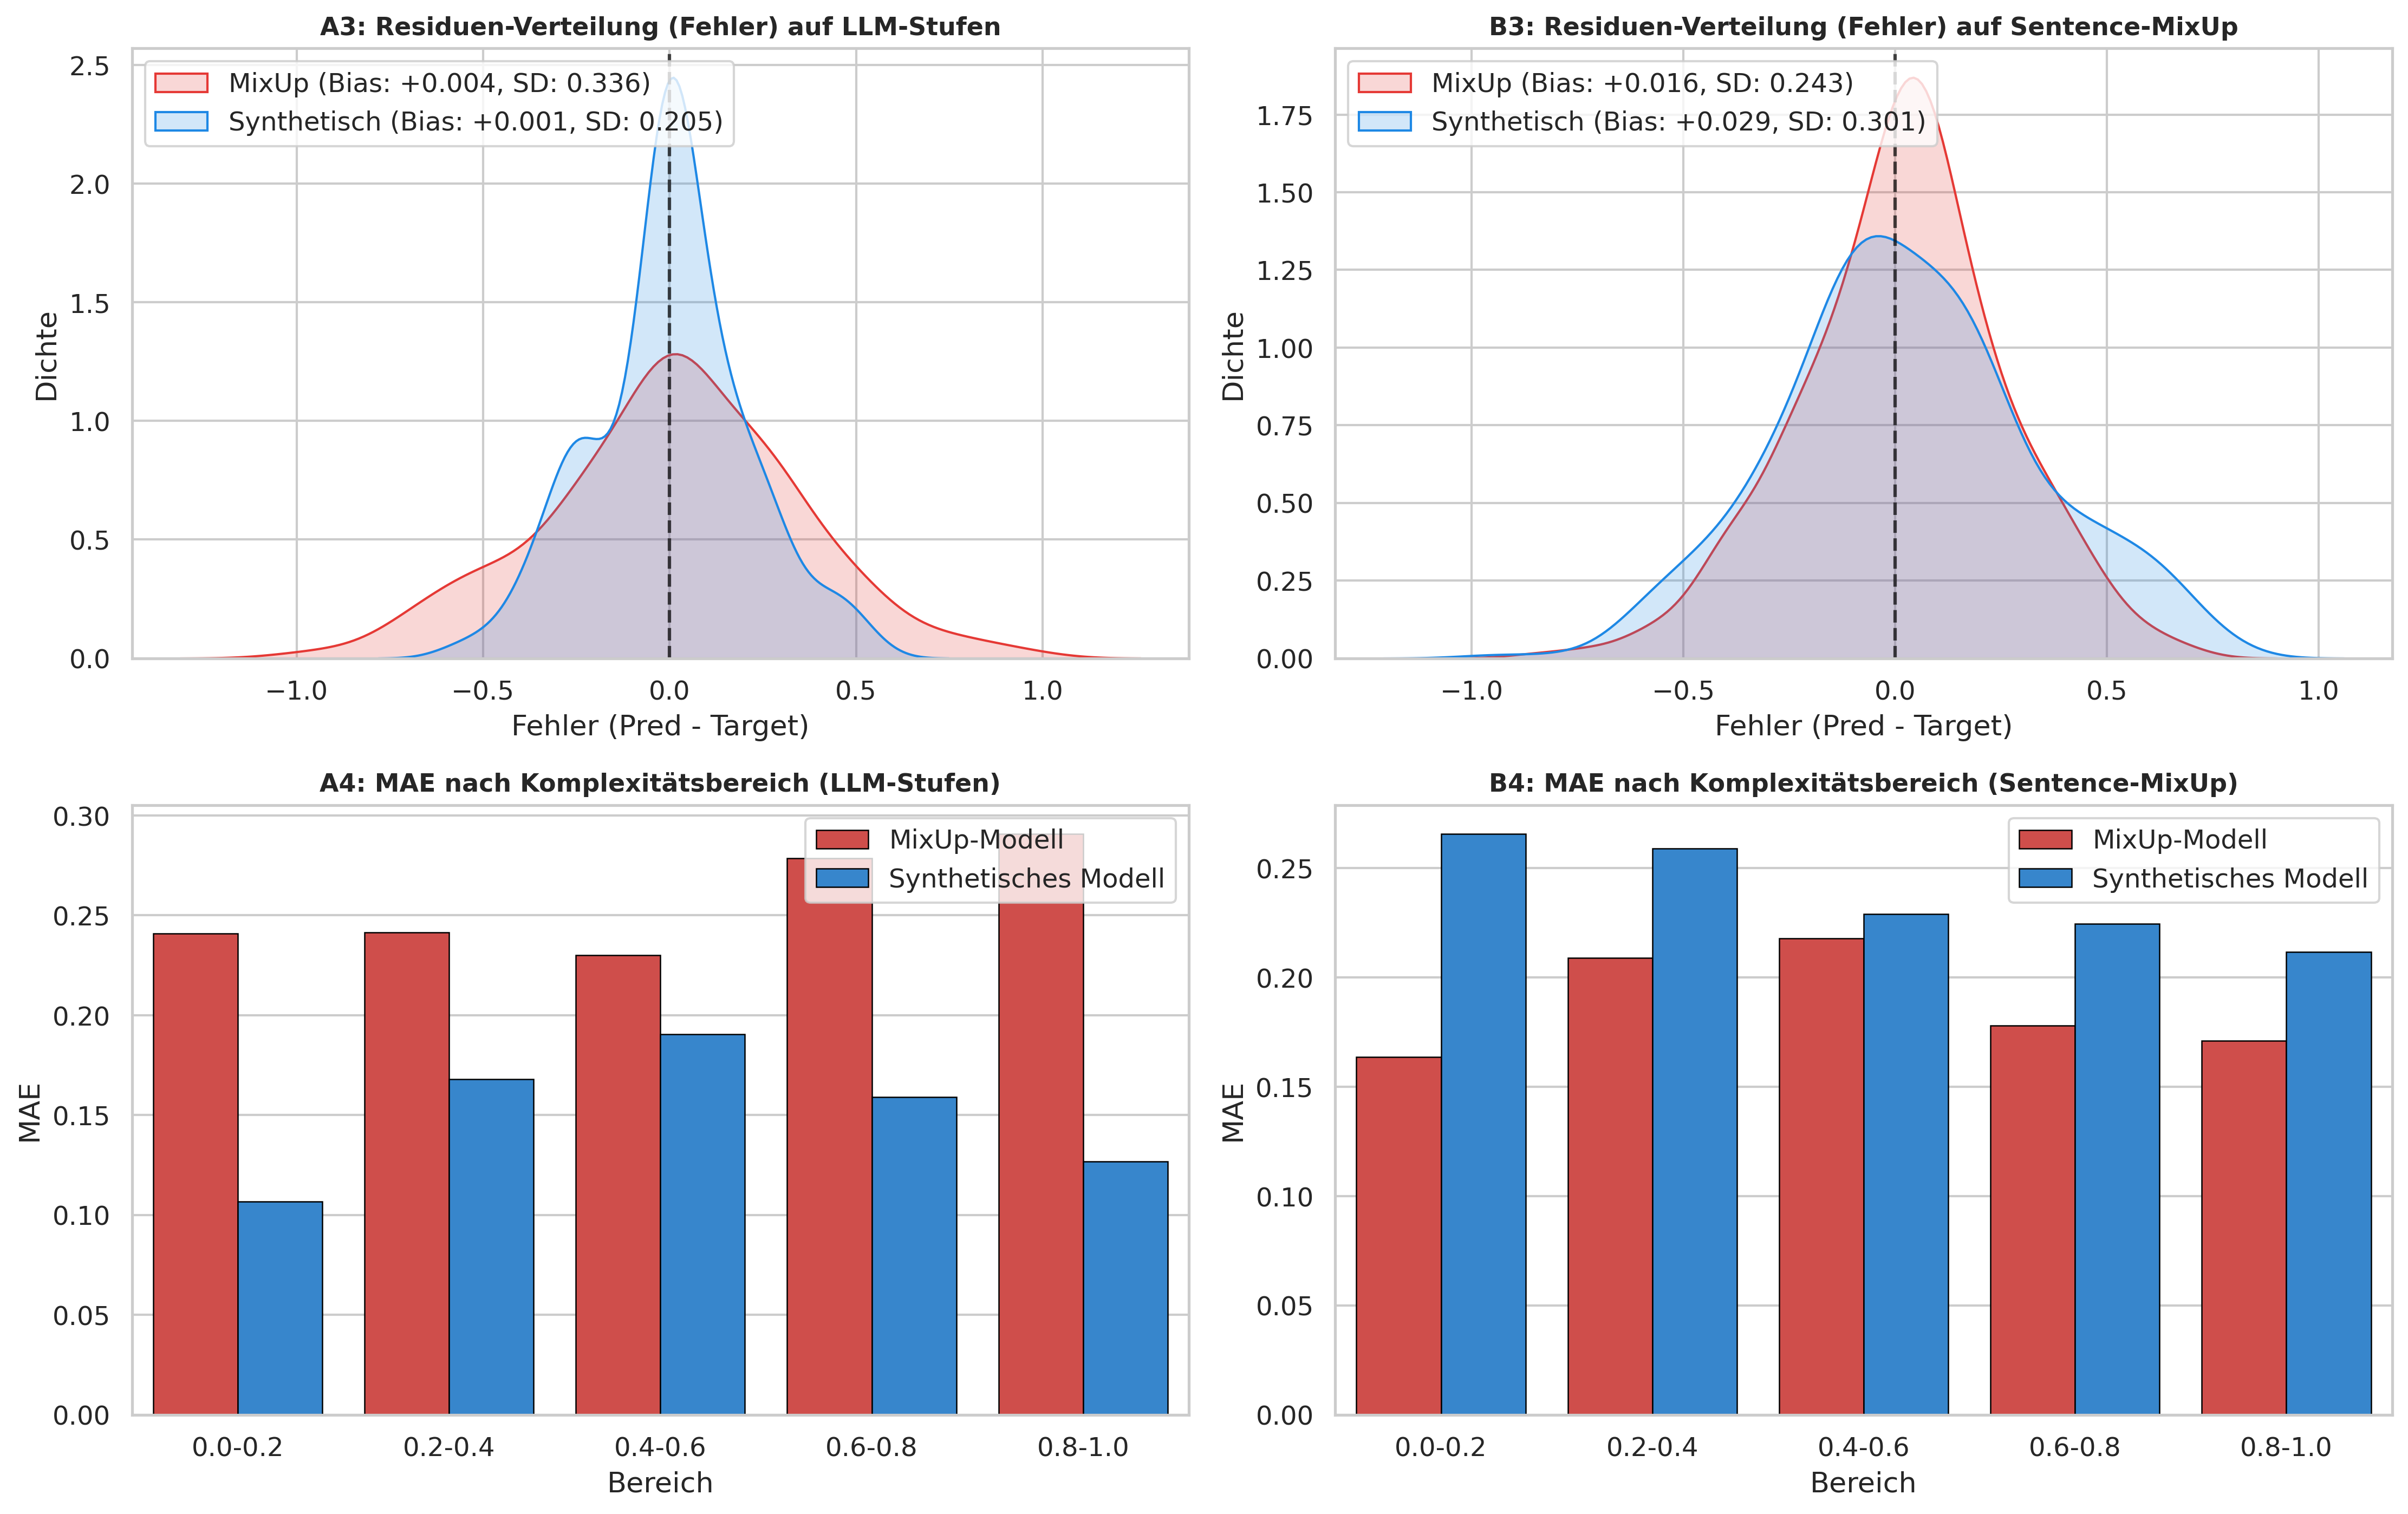

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9.5))

# A3: Residuen LLM-Stufen
res_m_a = preds_mixup_a - targets_a
res_s_a = preds_synth_a - targets_a
sns.kdeplot(res_m_a, label=f"MixUp (Bias: {np.mean(res_m_a):+.3f}, SD: {np.std(res_m_a):.3f})", color="#E53935", fill=True, alpha=0.2, ax=axes[0, 0])
sns.kdeplot(res_s_a, label=f"Synthetisch (Bias: {np.mean(res_s_a):+.3f}, SD: {np.std(res_s_a):.3f})", color="#1E88E5", fill=True, alpha=0.2, ax=axes[0, 0])
axes[0, 0].axvline(0, color="black", linestyle="--", alpha=0.7)
axes[0, 0].set_title("A3: Residuen-Verteilung (Fehler) auf LLM-Stufen", fontsize=11, fontweight="bold")
axes[0, 0].set_xlabel("Fehler (Pred - Target)")
axes[0, 0].set_ylabel("Dichte")
axes[0, 0].legend(loc="upper left")

# B3: Residuen Sentence-MixUp
res_m_b = preds_mixup_b - targets_b
res_s_b = preds_synth_b - targets_b
sns.kdeplot(res_m_b, label=f"MixUp (Bias: {np.mean(res_m_b):+.3f}, SD: {np.std(res_m_b):.3f})", color="#E53935", fill=True, alpha=0.2, ax=axes[0, 1])
sns.kdeplot(res_s_b, label=f"Synthetisch (Bias: {np.mean(res_s_b):+.3f}, SD: {np.std(res_s_b):.3f})", color="#1E88E5", fill=True, alpha=0.2, ax=axes[0, 1])
axes[0, 1].axvline(0, color="black", linestyle="--", alpha=0.7)
axes[0, 1].set_title("B3: Residuen-Verteilung (Fehler) auf Sentence-MixUp", fontsize=11, fontweight="bold")
axes[0, 1].set_xlabel("Fehler (Pred - Target)")
axes[0, 1].set_ylabel("Dichte")
axes[0, 1].legend(loc="upper left")

# A4: Binned MAE LLM-Stufen
bins_a = [0.0, 0.2, 0.4, 0.6, 0.8, 1.01]
bin_labels_a = ["0.0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]
df_binned_a = pd.DataFrame({
    "target": targets_a,
    "err_m": np.abs(preds_mixup_a - targets_a),
    "err_s": np.abs(preds_synth_a - targets_a),
    "bin": pd.cut(targets_a, bins=bins_a, labels=bin_labels_a, include_lowest=True)
})
mae_m_a = df_binned_a.groupby("bin", observed=False)["err_m"].mean()
mae_s_a = df_binned_a.groupby("bin", observed=False)["err_s"].mean()
df_plot_mae_a = pd.DataFrame({
    "Bereich": bin_labels_a * 2,
    "MAE": np.concatenate([mae_m_a.values, mae_s_a.values]),
    "Modell": ["MixUp-Modell"] * len(bin_labels_a) + ["Synthetisches Modell"] * len(bin_labels_a)
})
sns.barplot(data=df_plot_mae_a, x="Bereich", y="MAE", hue="Modell", palette=["#E53935", "#1E88E5"], ax=axes[1, 0], edgecolor="black", linewidth=0.6)
axes[1, 0].set_title("A4: MAE nach Komplexitätsbereich (LLM-Stufen)", fontsize=11, fontweight="bold")
axes[1, 0].set_ylabel("MAE")
axes[1, 0].legend(loc="upper right")

# B4: Binned MAE Sentence-MixUp
df_binned_b = pd.DataFrame({
    "target": targets_b,
    "err_m": np.abs(preds_mixup_b - targets_b),
    "err_s": np.abs(preds_synth_b - targets_b),
    "bin": pd.cut(targets_b, bins=bins_a, labels=bin_labels_a, include_lowest=True)
})
mae_m_b = df_binned_b.groupby("bin", observed=False)["err_m"].mean()
mae_s_b = df_binned_b.groupby("bin", observed=False)["err_s"].mean()
df_plot_mae_b = pd.DataFrame({
    "Bereich": bin_labels_a * 2,
    "MAE": np.concatenate([mae_m_b.values, mae_s_b.values]),
    "Modell": ["MixUp-Modell"] * len(bin_labels_a) + ["Synthetisches Modell"] * len(bin_labels_a)
})
sns.barplot(data=df_plot_mae_b, x="Bereich", y="MAE", hue="Modell", palette=["#E53935", "#1E88E5"], ax=axes[1, 1], edgecolor="black", linewidth=0.6)
axes[1, 1].set_title("B4: MAE nach Komplexitätsbereich (Sentence-MixUp)", fontsize=11, fontweight="bold")
axes[1, 1].set_ylabel("MAE")
axes[1, 1].legend(loc="upper right")

plt.tight_layout()
fig.savefig(os.path.join(PLOT_OUTPUT_DIR, "cross_validation_residuals_and_mae.png"), dpi=300, bbox_inches="tight")
plt.show()
